<a href="https://colab.research.google.com/github/Charan0622/Recommender-system-for-Beers-Dataset/blob/main/Beer_Recommender_Phase2_ItemCF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beer Recommender — Phase 2: Content-Boosted Item-CF

**Charan Sai Gandham** · SJSU ID 019142955

Team: Recommender Systems Final Project (BeerAdvocate + RateBeer, ~3.3M reviews)

Phase 2 individual variant

## Phase 1 recap

Phase 1 was the team's shared foundation. I owned the **item-based collaborative filtering** baseline. The idea is simple: to predict how user *u* will rate item *i*, look at items *u* has already rated, and weight those ratings by how similar each rated item is to *i* (cosine similarity on the centered user-item matrix, top-50 neighbors per item).

I compared three baselines on a per-user chronological 80/10/10 split. Validation results (417,856 ratings):

| Model | RMSE | MAE |
|---|---|---|
| Popularity (Bayesian) | 0.1203 | 0.0885 |
| User+Item Bias        | 0.1283 | 0.0960 |
| Item-Based CF (K=50)  | 0.1379 | 0.0990 |

Two takeaways from those numbers:

1. **The simple baselines beat Item-CF on RMSE/MAE.** That looks bad until you remember beer ratings are heavily skewed near the top of the scale — predicting "global mean" gets you a deceptively low error. The signal Item-CF actually adds shows up in *ranking* metrics, not error metrics. Phase 1 also reports Precision/Recall/NDCG @ 5/10/20 on a 1000-user sample, where Item-CF starts to pull ahead.
2. **We never used any beer metadata.** Item-CF only sees the rating matrix. But the dataset has style, brewery, ABV, and four sensory aspects per beer that we just left on the table. For tail items (very few ratings), the cosine similarity is basically noise because the column is mostly empty — so Phase 1 has no way to say "this rare beer is similar to that famous one because they're both Imperial Stouts brewed by the same brewery."

## My Phase 2 variant: Content-Boosted Item-CF

The cleanest way to "augment Item-CF with metadata" without throwing away the Phase 1 work is to keep the same Item-CF *scoring rule* and only swap out the *similarity it uses*. Instead of one similarity matrix from interactions, I build three and mix them with weights:

```
S(i, j) = α · S_int(i, j)  +  β · S_meta(i, j)  +  γ · S_sem(i, j)
                            with α + β + γ = 1
```

- **S_int** — cosine on the mean-centered user-item matrix. This is exactly the Phase 1 signal.
- **S_meta** — cosine on a feature vector built from style (one-hot), brewery (one-hot, rare ones merged), ABV (radial basis), and the four sensory aspects.
- **S_sem** — cosine on `all-MiniLM-L6-v2` sentence-transformer embeddings of a short beer descriptor (name, style, brewery, ABV).

The weights (α, β, γ) are picked by a grid search on the validation split. The user-level scoring is the standard Item-CF formula on this fused similarity.

Two things this design buys me:

- **The Phase 1 Item-CF is literally a corner of this model** (α = 1). So when I report both rows in the final table, the comparison is a clean ablation, not an apples-to-oranges swap. If CB-ItemCF beats Item-CF, I know it's the metadata that did it.
- **Cold items get a real signal again.** Even if a beer has 3 ratings (so its `S_int` column is mostly empty), `S_meta` and `S_sem` still produce meaningful neighbors based on what kind of beer it is. That's the failure mode I observed in Phase 1.

Method-direction-wise this is **Hybrid / multimodal** with an **LLM-augmented** component — both listed in the project brief.

## How my variant differs from my teammates' variants

Per the project brief, the three Phase 2 variants must differ in their core method or algorithm. Here's the lineup:

| Teammate | Variant | Algorithm family | Where the signal lives |
|---|---|---|---|
| Sai Chetan #1 | HybridNeuMF | Neural matrix factorization (GMF + MLP) | Learned latent embeddings; metadata fused inside an MLP |
| Sai Chetan #2 | MetadataSASRec | Sequential transformer (self-attention over user history) | Causal sequence model on ordered interactions |
| **Me (Charan)** | **CB-ItemCF** | **Linear mixture in similarity space** | **Closed-form item-item matrices, no learned embeddings, no sequence** |

So three genuinely different algorithm families: neural-latent, sequential-transformer, and similarity-space-mixture. Easy to defend in the oral exam.

**Why I picked this one specifically (and not, say, a graph-based or another neural method):**

- **It directly addresses the failure mode I personally observed in Phase 1.** I'm the Item-CF person; the cold-item problem is *my* problem. Fixing it with metadata + LLM embeddings is the most honest extension of my work.
- **It stays interpretable.** I can pull out the top-200 neighbors of any beer from each of the three similarity matrices and explain why they're there. NeuMF can't do that — its similarity is implicit in a learned vector. That's a real advantage when defending the model.
- **It needs no training.** The whole pipeline is sparse linear algebra + one forward pass through MiniLM. On the H100/A100 we're running on, every expensive step finishes in under a minute. No GPU-day training loops, no hyperparameter pain beyond the (α, β, γ) simplex.
- **It composes well with the team's story.** The final report can say: "we attacked the same recommendation problem from three angles — fuse in similarity space (CB-ItemCF), fuse in latent space (NeuMF), or model sequence (SASRec) — and here's what each angle is good at." That's a much cleaner narrative than three variants of the same neural model.

## Method overview

For every pair of beers (i, j), the fused item-item similarity is

```
S(i, j) = α · S_int + β · S_meta + γ · S_sem,    α + β + γ = 1
```

and the score for user u on candidate item i is the standard Item-CF aggregation on the fused similarity:

```
score(u, i) = Σ_{j ∈ R(u)} S(i, j) · (r_uj − mean_u)  /  Σ_{j ∈ R(u)} |S(i, j)|
```

The next 11 steps build each piece of this formula, tune the weights on validation, and evaluate every model side-by-side on test at K = 10.

## Step 1 — Setup

In [1]:
# 1a. Mount Drive (Colab-only; noop locally)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [2]:
# Install what Colab doesn't ship with
if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'sentence-transformers==3.0.1', 'nbformat'], check=True)

In [3]:
# 1c. Imports
import os, json, math, random, pickle, time, gc, gzip, ast
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix, save_npz, load_npz
from sklearn.preprocessing import normalize as sk_normalize
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

print('torch', torch.__version__, '| cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0),
          f'| VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

torch 2.10.0+cu128 | cuda: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition | VRAM: 102.0 GB


In [4]:
# 1d. Config — single source of truth. K=10 is non-negotiable.
#
# Data files live in Google Drive (mounted in Step 1a):
#   /content/drive/MyDrive/Colab Notebooks/beeradvocate.json.gz
#   /content/drive/MyDrive/Colab Notebooks/ratebeer.json.gz
# Step 3 parses both raw dumps on first run and caches df_combined.parquet
# next to them so subsequent runs are fast.

import sys
IN_COLAB = 'google.colab' in sys.modules

# ---- Working directory ----
if IN_COLAB:
    DRIVE_DIR     = Path('/content/drive/MyDrive/Colab Notebooks')
    PROJECT_DIR   = DRIVE_DIR
    ARTIFACTS_DIR = Path('/content/artifacts_cbitemcf')      # session scratch (fast I/O)
    REPORTS_DIR   = Path('/content/reports_cbitemcf')
else:
    PROJECT_DIR   = Path('/Users/spartan/Documents/College/Recommender System Project')
    ARTIFACTS_DIR = PROJECT_DIR / 'artifacts_cbitemcf'
    REPORTS_DIR   = PROJECT_DIR / 'reports_cbitemcf'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Input files ----
RAW_BEERADVOCATE = PROJECT_DIR / 'beeradvocate.json.gz'
RAW_RATEBEER     = PROJECT_DIR / 'ratebeer.json.gz'
COMBINED_PARQUET = PROJECT_DIR / 'df_combined.parquet'   # Step 3 caches here on first run

# ---- Optional teammate weights (only needed if you wire up Step 10e) ----
NEUMF_WEIGHTS_PATH  = PROJECT_DIR / 'hybrid_neumf_weights.pth'
SASREC_WEIGHTS_PATH = PROJECT_DIR / 'sasrec_best_weights.pth'
MF_WEIGHTS_PATH     = PROJECT_DIR / 'mf_model_weights.pth'
BASELINES_PKL       = PROJECT_DIR / 'baselines.pkl'

# ---- Protocol constants (must match Phase-1 ItemCF / LoadAndEval) ----
K                     = 10
K_LIST                = [5, 10, 20]
SEED                  = 42
RELEVANCE_THRESHOLD   = 0.7
EVAL_USER_SAMPLE      = 1000
GRID_EVAL_SAMPLE      = 500
MIN_USER_RATES        = 5
MIN_ITEM_RATES        = 5
KCORE_MAX_PASSES      = 5
MIN_USER_INTERACTIONS = 5
TOP_NEIGHBORS         = 200

# ---- Metadata block weights ----
META_W_STYLE      = 1.0
META_W_BREWERY    = 1.0
META_W_ABV        = 1.0
META_W_SENSORY    = 1.0
MIN_BREWERY_BEERS = 50

# ---- Sentence transformer ----
SBERT_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
SBERT_BATCH = 512

# ---- Reproducibility ----
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device       : {DEVICE}  |  K = {K}  |  seed = {SEED}')
print(f'project dir  : {PROJECT_DIR}')
print(f'artifacts dir: {ARTIFACTS_DIR}')

# ---- File status check ----
if COMBINED_PARQUET.exists():
    sz_mb = COMBINED_PARQUET.stat().st_size / 1e6
    print(f'data         : ✓ cached parquet ({sz_mb:.0f} MB) — Step 3 will load this')
elif RAW_BEERADVOCATE.exists() and RAW_RATEBEER.exists():
    sz_ba = RAW_BEERADVOCATE.stat().st_size / 1e6
    sz_rb = RAW_RATEBEER.stat().st_size / 1e6
    print(f'data         : ✓ raw dumps present (BA: {sz_ba:.0f} MB, RB: {sz_rb:.0f} MB)')
    print(f'               Step 3 will parse + cache parquet to {PROJECT_DIR}')
else:
    print(f'data         : ✗ NOT FOUND in {PROJECT_DIR}')
    print(f'               expected beeradvocate.json.gz and ratebeer.json.gz')

device       : cuda  |  K = 10  |  seed = 42
project dir  : /content/drive/MyDrive/Colab Notebooks
artifacts dir: /content/artifacts_cbitemcf
data         : ✓ cached parquet (45 MB) — Step 3 will load this


## Step 2 — Pin the evaluation protocol

I lifted the protocol straight from my Phase 1 ItemCF notebook and the teammate's LoadAndEval notebook so the rows in the final Phase 2 table are directly comparable across all three variants: per-user chronological 80/10/10 split, K_LIST = [5, 10, 20], relevance threshold 0.7, all-unseen-items ranking pool, seed 42, 1000-user evaluation sample. The `RECONCILED` dict below is the single place to change anything if the team agrees later.

In [5]:
RECONCILED = {
    'SEED':                SEED,
    'K':                   K,
    'K_LIST':              K_LIST,
    'SPLIT_RULE':          'per_user_chronological_80_10_10',
    'CANDIDATE_POOL':      'all_items_not_seen_in_train',
    'RELEVANCE_THRESHOLD': RELEVANCE_THRESHOLD,
    'MIN_USER_RATES':      MIN_USER_RATES,
    'MIN_ITEM_RATES':      MIN_ITEM_RATES,
    'EVAL_USER_SAMPLE':    EVAL_USER_SAMPLE,
    'HR_AT_K':             'binary — 1 if any relevant item in top-K',
    'NDCG_AT_K':           'binary gain, discount = 1/log2(rank+2)',
}
print('Reconciled protocol:')
for k, v in RECONCILED.items():
    print(f'  {k:22s} = {v}')

Reconciled protocol:
  SEED                   = 42
  K                      = 10
  K_LIST                 = [5, 10, 20]
  SPLIT_RULE             = per_user_chronological_80_10_10
  CANDIDATE_POOL         = all_items_not_seen_in_train
  RELEVANCE_THRESHOLD    = 0.7
  MIN_USER_RATES         = 5
  MIN_ITEM_RATES         = 5
  EVAL_USER_SAMPLE       = 1000
  HR_AT_K                = binary — 1 if any relevant item in top-K
  NDCG_AT_K              = binary gain, discount = 1/log2(rank+2)


## Step 3 — Load data, filter, split

Load the merged BeerAdvocate + RateBeer dataset (parquet if I cached it last run, otherwise parse the raw json.gz and cache for next time), apply the same k-core filter as Phase 1, then do the per-user chronological split. Outputs: `R_train` (sparse rating matrix), `df_items` (per-item metadata), and `val_relevant` / `test_relevant` (the per-user relevant-item sets used for ranking eval).

In [6]:
# 3a. Robust loader — JSON-lines dumps use mix of strict JSON and Python literals
RATING_COLS = ['review/overall','review/appearance','review/aroma','review/palate','review/taste']
KEEP_COLS   = ['review/profileName','review/time'] + RATING_COLS + \
              ['beer/beerId','beer/name','beer/style','beer/ABV','beer/brewerId']

def _parse_line(line):
    line = line.strip()
    if not line: return None
    try:   return json.loads(line)
    except Exception:
        try: return ast.literal_eval(line)
        except Exception: return None

def _load_dump(path):
    opener = gzip.open if str(path).endswith('.gz') else open
    rows = []
    with opener(path, 'rt', encoding='utf-8', errors='ignore') as f:
        for line in tqdm(f, desc=f'parse {Path(path).name}', mininterval=2.0):
            rec = _parse_line(line)
            if rec is None: continue
            rows.append({k: rec.get(k) for k in KEEP_COLS})
    return pd.DataFrame(rows)

def _frac_to_float(x):
    if isinstance(x, (int, float)): return float(x)
    if isinstance(x, str) and '/' in x:
        try:
            n, d = x.split('/'); n, d = float(n), float(d)
            return n / d if d else np.nan
        except Exception: return np.nan
    try: return float(x)
    except Exception: return np.nan

if COMBINED_PARQUET.exists():
    print(f'Loading cached combined dataframe: {COMBINED_PARQUET}')
    df_raw = pd.read_parquet(COMBINED_PARQUET)
else:
    assert RAW_BEERADVOCATE.exists() and RAW_RATEBEER.exists(), (
        f'Neither {COMBINED_PARQUET} nor {RAW_BEERADVOCATE}/{RAW_RATEBEER} found. '
        f'Upload the raw .json.gz files to {PROJECT_DIR}.'
    )
    t0 = time.time()
    ba = _load_dump(RAW_BEERADVOCATE); ba['source'] = 'BA'
    rb = _load_dump(RAW_RATEBEER);     rb['source'] = 'RB'
    for c in RATING_COLS:
        ba[c] = ba[c].map(_frac_to_float)
        rb[c] = rb[c].map(_frac_to_float)
    # BeerAdvocate ratings are on 0-5; normalize to [0,1] to match RateBeer
    if ba['review/overall'].dropna().max() > 1.5:
        ba[RATING_COLS] = ba[RATING_COLS] / 5.0
    if rb['review/overall'].dropna().max() > 1.5:
        rb[RATING_COLS] = rb[RATING_COLS] / 5.0
    df_raw = pd.concat([ba, rb], ignore_index=True)
    df_raw['item_id'] = df_raw['source'].astype(str) + '_' + df_raw['beer/beerId'].astype(str)
    df_raw = df_raw.dropna(subset=['review/profileName','review/overall','item_id']).copy()
    df_raw['review/overall'] = df_raw['review/overall'].clip(0.0, 1.0).astype(np.float32)
    df_raw['review/time']    = pd.to_numeric(df_raw['review/time'], errors='coerce')
    df_raw = df_raw.dropna(subset=['review/time']).copy()
    df_raw['review/time']    = df_raw['review/time'].astype(np.int64)
    df_raw['beer/ABV']       = pd.to_numeric(df_raw['beer/ABV'], errors='coerce')
    df_raw.to_parquet(COMBINED_PARQUET, index=False)
    print(f'Loaded + merged in {time.time()-t0:.1f}s; cached to {COMBINED_PARQUET}')

print(f'\ndf_raw: {len(df_raw):,} rows')
df_raw.head(2)

Loading cached combined dataframe: /content/drive/MyDrive/Colab Notebooks/df_combined.parquet

df_raw: 4,510,777 rows


,review/profileName,review/time,review/overall,review/appearance,review/aroma,review/palate,review/taste,beer/beerId,beer/name,beer/style,beer/ABV,beer/brewerId,source,item_id
0,stcules,1234817823,0.3,0.5,0.4,0.3,0.3,47986,Sausa Weizen,Hefeweizen,5.0,10325,BA,BA_47986
1,stcules,1235915097,0.6,0.6,0.5,0.6,0.6,48213,Red Moon,English Strong Ale,6.2,10325,BA,BA_48213


In [7]:
# 3b. Standardize column names so the rest of the notebook is source-agnostic
rename_map = {
    'review/profileName': 'user_id',
    'review/time':        'timestamp',
    'review/overall':     'rating',
    'review/appearance':  'appearance',
    'review/aroma':       'aroma',
    'review/palate':      'palate',
    'review/taste':       'taste',
    'beer/name':          'name',
    'beer/style':         'style',
    'beer/ABV':           'abv',
    'beer/brewerId':      'brewery',
}
df = df_raw.rename(columns=rename_map).copy()
# item_id is already present (composed in 3a if loaded from json, else shipped in parquet)
if 'item_id' not in df.columns:
    df['item_id'] = df['source'].astype(str) + '_' + df['beer/beerId'].astype(str)
# Keep only what we need from here on
df = df[['user_id','item_id','rating','timestamp','style','brewery','abv',
         'appearance','aroma','palate','taste','name']].copy()
print('standardized columns:', list(df.columns))
print(f'{len(df):,} rows | {df.user_id.nunique():,} users | {df.item_id.nunique():,} items')
df.head(2)

standardized columns: ['user_id', 'item_id', 'rating', 'timestamp', 'style', 'brewery', 'abv', 'appearance', 'aroma', 'palate', 'taste', 'name']
4,510,777 rows | 60,786 users | 176,424 items


,user_id,item_id,rating,timestamp,style,brewery,abv,appearance,aroma,palate,taste,name
0,stcules,BA_47986,0.3,1234817823,Hefeweizen,10325,5.0,0.5,0.4,0.3,0.3,Sausa Weizen
1,stcules,BA_48213,0.6,1235915097,English Strong Ale,10325,6.2,0.6,0.5,0.6,0.6,Red Moon


In [8]:
# 3c. k-core filtering (iterate until stable; matches Phase-1)
def k_core_filter(df, min_user=MIN_USER_RATES, min_item=MIN_ITEM_RATES, max_iter=KCORE_MAX_PASSES):
    for it in range(max_iter):
        n0 = len(df)
        uc = df.groupby('user_id').size()
        ic = df.groupby('item_id').size()
        keep_u = set(uc[uc >= min_user].index)
        keep_i = set(ic[ic >= min_item].index)
        mask = df.user_id.isin(keep_u) & df.item_id.isin(keep_i)
        df = df[mask]
        print(f'  pass {it+1}: {n0:,} -> {len(df):,}')
        if len(df) == n0: break
    return df.reset_index(drop=True)

df = k_core_filter(df)
print(f'after k-core: {len(df):,} rows | {df.user_id.nunique():,} users | {df.item_id.nunique():,} items')

  pass 1: 4,510,777 -> 4,263,757
  pass 2: 4,263,757 -> 4,261,266
  pass 3: 4,261,266 -> 4,261,066
  pass 4: 4,261,066 -> 4,261,062
  pass 5: 4,261,062 -> 4,261,062
after k-core: 4,261,062 rows | 26,714 users | 75,787 items


In [9]:
# 3d. Per-user chronological 80/10/10 split (deterministic, matches Phase-1 ItemCF)
def chronological_split(df, min_interactions=MIN_USER_INTERACTIONS):
    df_sorted = df.sort_values(['user_id','timestamp']).reset_index(drop=True)
    train_parts, val_parts, test_parts = [], [], []
    for _, g in tqdm(df_sorted.groupby('user_id', sort=False), desc='per-user split'):
        n = len(g)
        if n < min_interactions:
            train_parts.append(g); continue
        n_test  = max(1, int(round(0.1 * n)))
        n_val   = max(1, int(round(0.1 * n)))
        n_train = n - n_val - n_test
        if n_train < 1:
            n_train, n_val, n_test = n - 2, 1, 1
        train_parts.append(g.iloc[:n_train])
        val_parts  .append(g.iloc[n_train:n_train + n_val])
        test_parts .append(g.iloc[n_train + n_val:])
    return (pd.concat(train_parts, ignore_index=True),
            pd.concat(val_parts,   ignore_index=True) if val_parts   else df.iloc[:0],
            pd.concat(test_parts,  ignore_index=True) if test_parts  else df.iloc[:0])

train_df, val_df, test_df = chronological_split(df)
print(f'train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}')

per-user split:   0%|          | 0/26714 [00:00<?, ?it/s]

train: 3,404,180 | val: 428,441 | test: 428,441


In [10]:
# 3e. Build user2idx / item2idx from TRAIN ONLY (matches Phase-1). Drop val/test rows
# that reference unseen users/items.
unique_users = sorted(train_df['user_id'].unique())
unique_items = sorted(train_df['item_id'].unique())
user2idx = {u: i for i, u in enumerate(unique_users)}
item2idx = {b: i for i, b in enumerate(unique_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: b for b, i in item2idx.items()}
N_USERS, N_ITEMS = len(user2idx), len(item2idx)

def _add_idx(frame):
    f = frame[frame['user_id'].isin(user2idx) & frame['item_id'].isin(item2idx)].copy()
    f['u'] = f['user_id'].map(user2idx).astype(np.int32)
    f['i'] = f['item_id'].map(item2idx).astype(np.int32)
    return f

train_df = _add_idx(train_df)
val_df   = _add_idx(val_df)
test_df  = _add_idx(test_df)
print(f'{N_USERS:,} users × {N_ITEMS:,} items | '
      f'density = {len(train_df) / (N_USERS * N_ITEMS) * 100:.4f}%')

R_train = csr_matrix(
    (train_df.rating.values.astype(np.float32),
     (train_df.u.values, train_df.i.values)),
    shape=(N_USERS, N_ITEMS))
R_train.sum_duplicates()
print(f'R_train nnz = {R_train.nnz:,}')

26,714 users × 74,240 items | density = 0.1716%
R_train nnz = 3,343,473


In [11]:
def _mode(series):
    # Returns the most frequent value. Handles cases with multiple modes by returning the first.
    # Returns NaN if the series is empty.
    modes = series.mode()
    if not modes.empty:
        return modes.iloc[0]
    return np.nan

agg = train_df.groupby('i').agg(
    n_reviews      = ('rating',    'size'),
    mean_rating    = ('rating',    'mean'),
    mean_appearance= ('appearance','mean'),
    mean_aroma     = ('aroma',     'mean'),
    mean_palate    = ('palate',    'mean'),
    mean_taste     = ('taste',     'mean'),
    name           = ('name',      _mode),
    style          = ('style',     _mode),
    brewery        = ('brewery',   _mode),
    abv            = ('abv',       'mean'),
    item_id        = ('item_id',   'first'),
).reset_index()

df_items = agg.sort_values('i').reset_index(drop=True)
assert (df_items['i'].values == np.arange(N_ITEMS)).all(), 'item index misalignment'

df_items['style']   = df_items['style'].fillna('UNKNOWN').astype(str)
df_items['brewery'] = df_items['brewery'].fillna('UNKNOWN').astype(str)
df_items['abv']     = df_items['abv'].fillna(df_items['abv'].median()).astype(np.float32)
for c in ['mean_appearance','mean_aroma','mean_palate','mean_taste','mean_rating']:
    df_items[c] = df_items[c].fillna(df_items[c].median()).astype(np.float32)

print(f'df_items: {len(df_items):,} rows | styles: {df_items['style'].nunique()} | '
      f'breweries: {df_items['brewery'].nunique()}')
df_items.head(3)

df_items: 74,240 rows | styles: 179 | breweries: 6834


,i,n_reviews,mean_rating,mean_appearance,mean_aroma,mean_palate,mean_taste,name,style,brewery,abv,item_id
0,0,637,0.764050,0.789482,0.749451,0.749294,0.751491,Allagash Dubbel Ale,Dubbel,4,7.00,BA_10
1,1,511,0.625245,0.688258,0.599804,0.610959,0.592368,Blue Moon Harvest Moon Pumpkin Ale,Pumpkin Ale,306,5.70,BA_100
2,2,74,0.779730,0.777027,0.743243,0.758108,0.771622,Winter Brew,Bock,144,5.75,BA_1000


In [12]:
# 3g. Per-user relevant-item sets for val/test (rating >= RELEVANCE_THRESHOLD)
def build_relevant(frame, threshold=RELEVANCE_THRESHOLD):
    rel = frame[frame['rating'] >= threshold]
    out = defaultdict(set)
    for u, i in zip(rel['u'].values, rel['i'].values):
        out[int(u)].add(int(i))
    return out

val_relevant  = build_relevant(val_df)
test_relevant = build_relevant(test_df)
print(f'val  users w/ ≥1 relevant held-out item: {len(val_relevant):,}')
print(f'test users w/ ≥1 relevant held-out item: {len(test_relevant):,}')

val  users w/ ≥1 relevant held-out item: 23,103
test users w/ ≥1 relevant held-out item: 23,321


## Step 4 — Interaction similarity (S_int)

This is the Phase 1 signal. Subtract each user's mean rating, take item-item cosine on the centered sparse matrix, keep the top 200 neighbors per item. Sanity check: when α = 1 in Step 9, CB-ItemCF must produce essentially the same numbers as Phase 1 Item-CF — that's how I know the pipeline isn't lying.

In [13]:
def mean_center_rows(R):
    '''Subtract each user's mean rating from their nonzero entries.'''
    R = R.tocsr().astype(np.float32).copy()
    sums   = np.asarray(R.sum(axis=1)).ravel()
    counts = np.diff(R.indptr).astype(np.float32)
    means  = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    for u in range(R.shape[0]):
        s, e = R.indptr[u], R.indptr[u+1]
        if s < e:
            R.data[s:e] -= means[u]
    return R, means

def top_k_per_row_sparse(M, k):
    '''Keep only the top-k entries per row of a sparse matrix.'''
    M = M.tocsr()
    rows, cols, vals = [], [], []
    for r in range(M.shape[0]):
        s, e = M.indptr[r], M.indptr[r+1]
        if e == s: continue
        rv, rc = M.data[s:e], M.indices[s:e]
        if len(rv) > k:
            top_idx = np.argpartition(-rv, k)[:k]
            rv, rc = rv[top_idx], rc[top_idx]
        rows.extend([r]*len(rv)); cols.extend(rc.tolist()); vals.extend(rv.tolist())
    return csr_matrix((np.asarray(vals, dtype=np.float32),
                       (np.asarray(rows, dtype=np.int32),
                        np.asarray(cols, dtype=np.int32))),
                      shape=M.shape)

In [14]:
S_INT_PATH = ARTIFACTS_DIR / 'S_int_top200.npz'
if S_INT_PATH.exists():
    S_int = load_npz(str(S_INT_PATH))
    print(f'loaded cached S_int: shape={S_int.shape} nnz={S_int.nnz:,}')
else:
    t0 = time.time()
    R_centered, user_means = mean_center_rows(R_train)
    # items × users, L2-normalized per row -> inner product == cosine
    R_c_item = sk_normalize(R_centered.T.tocsr(), norm='l2', axis=1, copy=True)
    S_int_full = R_c_item @ R_c_item.T
    S_int_full.setdiag(0); S_int_full.eliminate_zeros()
    S_int = top_k_per_row_sparse(S_int_full, TOP_NEIGHBORS)
    save_npz(str(S_INT_PATH), S_int)
    print(f'S_int built in {time.time()-t0:.1f}s | shape={S_int.shape} nnz={S_int.nnz:,}')
    del S_int_full, R_centered, R_c_item; gc.collect()

# Expose user_means (needed by scoring) even when loading from cache
if 'user_means' not in globals():
    _, user_means = mean_center_rows(R_train)

S_int built in 35.7s | shape=(74240, 74240) nnz=14,764,620


In [15]:
# Sanity check: top-5 neighbors of popular beers in a few styles
def top_neighbors(item_idx, sim, k=10):
    row = sim.getrow(item_idx).toarray().ravel()
    top = np.argsort(-row)[:k]
    return [(df_items.loc[j,'name'], df_items.loc[j,'style'], float(row[j]))
            for j in top if row[j] > 0]

for style_kw in ['IPA', 'Stout', 'Pilsner']:
    m = df_items[df_items['style'].str.contains(style_kw, case=False, na=False)]
    if m.empty: continue
    q = m.sort_values('n_reviews', ascending=False).iloc[0]
    print(f'\nNeighbors of "{q["name"]}" ({q.style}):')
    for nb in top_neighbors(int(q['i']), S_int)[:5]:
        print(f'  {nb}')


Neighbors of "90 Minute IPA" (American Double / Imperial IPA):
  ('Stone IPA (India Pale Ale)', 'American IPA', 0.2317817211151123)
  ('60 Minute IPA', 'American IPA', 0.22275368869304657)
  ('HopDevil Ale', 'American IPA', 0.21327872574329376)
  ('Hop Rod Rye', 'Rye Beer', 0.2087841033935547)
  ('Racer 5 India Pale Ale', 'American IPA', 0.20247861742973328)

Neighbors of "Guinness Draught" (Dry Stout):
  ('Guinness Extra Stout &#40;North America&#41;', 'Dry Stout', 0.1864057183265686)
  ('Bass Pale Ale', 'Premium Bitter/ESB', 0.18053242564201355)
  ('Beamish Irish Stout', 'Dry Stout', 0.17160847783088684)
  ('Newcastle Brown Ale', 'Brown Ale', 0.15555302798748016)
  ('Kilkenny', 'Irish Ale', 0.14554034173488617)

Neighbors of "Samuel Adams Hallertau Imperial Pilsner" (American Double / Imperial Pilsner):
  ('LuvBuzz  Espresso Stout', 'American Stout', 0.22251664102077484)
  ('Green Monsta Ale', 'English Pale Ale', 0.20943637192249298)
  ('McGilligans IPA', 'American IPA', 0.172953203

## Step 5 — Metadata similarity (S_meta)

Build a feature vector for each beer from four blocks: style (one-hot), brewery (one-hot with rare breweries merged into OTHER), ABV (3-bump radial basis so similar ABVs are close), and the four sensory aspects (appearance, aroma, palate, taste — z-scored). Each block has its own weight. Then chunked cosine top-200 on GPU.

In [16]:
# 5a. Build the item feature matrix
style_dummies = pd.get_dummies(df_items['style'].fillna('UNK'), prefix='style').astype(np.float32)

brewery_counts = df_items.brewery.value_counts()
kept_brew = set(brewery_counts[brewery_counts >= MIN_BREWERY_BEERS].index)
df_items['brewery_agg'] = df_items.brewery.where(df_items.brewery.isin(kept_brew), 'OTHER')
brew_dummies = pd.get_dummies(df_items['brewery_agg'].fillna('UNK'), prefix='brew').astype(np.float32)

abv = df_items.abv.values.astype(np.float32)
abv_z = (abv - abv.mean()) / (abv.std() + 1e-8)
centers = np.array([-1.0, 0.0, 1.0], dtype=np.float32)
abv_rbf = np.exp(-0.5 * (abv_z[:, None] - centers[None, :]) ** 2).astype(np.float32)

sens_cols = ['mean_appearance','mean_aroma','mean_palate','mean_taste']
sens = df_items[sens_cols].values.astype(np.float32)
sens = (sens - sens.mean(axis=0)) / (sens.std(axis=0) + 1e-8)

F_style = style_dummies.values * META_W_STYLE
F_brew  = brew_dummies.values  * META_W_BREWERY
F_abv   = abv_rbf               * META_W_ABV
F_sens  = sens                  * META_W_SENSORY

F_all = np.hstack([F_style, F_brew, F_abv, F_sens]).astype(np.float32)
print(f'feature matrix: {F_all.shape}  (items × features)')
print(f'  style={F_style.shape[1]}  brewery={F_brew.shape[1]}  abv={F_abv.shape[1]}  sensory={F_sens.shape[1]}')

feature matrix: (74240, 416)  (items × features)
  style=179  brewery=230  abv=3  sensory=4


In [17]:
# 5b. Chunked cosine top-k on GPU (fp16 for speed; results cast back to fp32)
def chunked_cosine_topk_gpu(X, k, chunk=2048, device='cuda', fp16=True):
    '''X: (n, d) numpy -> sparse CSR of top-k cosine sims (self excluded).'''
    dtype = torch.float16 if (fp16 and device == 'cuda') else torch.float32
    X = torch.as_tensor(X, dtype=dtype, device=device)
    X = F.normalize(X, p=2, dim=1)
    n = X.shape[0]
    rows, cols, vals = [], [], []
    for s in tqdm(range(0, n, chunk), desc='cosine top-k'):
        e = min(s + chunk, n)
        S_block = X[s:e] @ X.T                                       # (chunk, n)
        S_block[torch.arange(e-s, device=device),
                torch.arange(s, e, device=device)] = 0               # zero self
        topv, topi = torch.topk(S_block, k=k, dim=1)
        rr = torch.arange(s, e, device=device).unsqueeze(1).expand_as(topi)
        rows.append(rr.reshape(-1).cpu().numpy())
        cols.append(topi.reshape(-1).cpu().numpy())
        vals.append(topv.reshape(-1).float().cpu().numpy())
        del S_block, topv, topi
    rows = np.concatenate(rows); cols = np.concatenate(cols); vals = np.concatenate(vals)
    # drop zero/negative sims to keep the matrix interpretable as similarity
    keep = vals > 0
    return csr_matrix((vals[keep], (rows[keep], cols[keep])), shape=(n, n))

S_META_PATH = ARTIFACTS_DIR / 'S_meta_top200.npz'
if S_META_PATH.exists():
    S_meta = load_npz(str(S_META_PATH))
    print(f'loaded cached S_meta: nnz={S_meta.nnz:,}')
else:
    t0 = time.time()
    S_meta = chunked_cosine_topk_gpu(F_all, k=TOP_NEIGHBORS, chunk=2048,
                                     device=DEVICE, fp16=True)
    save_npz(str(S_META_PATH), S_meta)
    print(f'S_meta in {time.time()-t0:.1f}s | nnz={S_meta.nnz:,}')
if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()

cosine top-k:   0%|          | 0/37 [00:00<?, ?it/s]

S_meta in 11.1s | nnz=14,848,000


18

## Step 6 — Semantic similarity (S_sem) — the LLM-augmented part

Build a short text descriptor per beer (name, style, brewery, ABV), encode with `all-MiniLM-L6-v2`, then cosine top-200 with the same GPU helper. This is what gives the model a way to say "Russian Imperial Stout" is closer to "American Imperial Stout" than to "Pilsner" even when neither has many ratings yet.

In [18]:
# 6a. Build descriptor strings for each item
def make_descriptor(row):
    parts = [str(row['name']) if pd.notna(row['name']) else 'Beer']
    if pd.notna(row.style)   and row.style   != 'UNKNOWN': parts.append(f'Style: {row.style}')
    if pd.notna(row.brewery) and row.brewery != 'UNKNOWN': parts.append(f'Brewery: {row.brewery}')
    if pd.notna(row.abv):                                  parts.append(f'ABV: {row.abv:.2f}%')
    return '. '.join(parts)

descriptors = df_items.apply(make_descriptor, axis=1).tolist()
print('example descriptors:')
for d in descriptors[:3]: print(' ', d)

example descriptors:
  Allagash Dubbel Ale. Style: Dubbel. Brewery: 4. ABV: 7.00%
  Blue Moon Harvest Moon Pumpkin Ale. Style: Pumpkin Ale. Brewery: 306. ABV: 5.70%
  Winter Brew. Style: Bock. Brewery: 144. ABV: 5.75%


In [19]:
# 6b. Encode with MiniLM (GPU if available), cache to Drive
EMB_PATH = ARTIFACTS_DIR / 'semantic_emb.npy'
if EMB_PATH.exists():
    embeddings = np.load(EMB_PATH)
    print(f'loaded cached embeddings: {embeddings.shape}')
else:
    from sentence_transformers import SentenceTransformer
    t0 = time.time()
    sbert = SentenceTransformer(SBERT_MODEL, device=DEVICE)
    embeddings = sbert.encode(
        descriptors,
        batch_size=SBERT_BATCH,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    np.save(EMB_PATH, embeddings)
    print(f'encoded {len(descriptors)} items in {time.time()-t0:.1f}s | shape={embeddings.shape}')
    del sbert
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/145 [00:00<?, ?it/s]

encoded 74240 items in 9.1s | shape=(74240, 384)


In [20]:
# 6c. Cosine top-k on GPU
S_SEM_PATH = ARTIFACTS_DIR / 'S_sem_top200.npz'
if S_SEM_PATH.exists():
    S_sem = load_npz(str(S_SEM_PATH))
    print(f'loaded cached S_sem: nnz={S_sem.nnz:,}')
else:
    t0 = time.time()
    S_sem = chunked_cosine_topk_gpu(embeddings, k=TOP_NEIGHBORS, chunk=2048,
                                    device=DEVICE, fp16=True)
    save_npz(str(S_SEM_PATH), S_sem)
    print(f'S_sem in {time.time()-t0:.1f}s | nnz={S_sem.nnz:,}')

# Semantic sanity: nearest neighbors of a popular IPA should be other hop-forward styles
m = df_items[df_items['style'].str.contains('IPA', case=False, na=False)]
if not m.empty:
    q = m.sort_values('n_reviews', ascending=False).iloc[0]
    print(f'\nSemantic neighbors of "{q["name"]}" ({q['style']}):')
    for nb in top_neighbors(int(q['i']), S_sem)[:5]:
        print(f'  {nb}')

cosine top-k:   0%|          | 0/37 [00:00<?, ?it/s]

S_sem in 10.3s | nnz=14,848,000

Semantic neighbors of "90 Minute IPA" (American Double / Imperial IPA):
  ('120 Minute IPA', 'American Double / Imperial IPA', 0.9599609375)
  ('75 Minute IPA', 'American IPA', 0.92724609375)
  ('60 Minute IPA', 'American IPA', 0.9189453125)
  ('Double IPA', 'American Double / Imperial IPA', 0.908203125)
  ('Imperial IPA', 'American Double / Imperial IPA', 0.9072265625)


## Step 7 — Fuse and score

I don't pre-fuse the three matrices into one (that would force an early top-200 truncation and lose information). Instead, for a user u, I compute the three numerator contributions separately, weight them, then divide by the fused row-sum of absolute similarities. Stays exact for any (α, β, γ).

In [21]:
# 7a. Pre-compute the absolute-value versions of the three sim matrices (for |S| denom)
S_int_abs  = S_int.copy();  S_int_abs.data  = np.abs(S_int_abs.data)
S_meta_abs = S_meta.copy(); S_meta_abs.data = np.abs(S_meta_abs.data)
S_sem_abs  = S_sem.copy();  S_sem_abs.data  = np.abs(S_sem_abs.data)

# Per-user rating vector helper (CSR row)
def _user_rated(u):
    s, e = R_train.indptr[u], R_train.indptr[u+1]
    return R_train.indices[s:e], R_train.data[s:e]

def user_full_scores(u, alpha, beta, gamma, mask_seen=True):
    '''Return a dense length-N_ITEMS score vector for user u under (alpha, beta, gamma).'''
    items_u, ratings_u = _user_rated(u)
    if len(items_u) == 0:
        # cold user: fall back to popularity-like content score (no interaction term)
        return np.zeros(N_ITEMS, dtype=np.float32)
    mean_u   = float(ratings_u.mean())
    centered = ratings_u - mean_u
    mask_vec = np.zeros(N_ITEMS, dtype=np.float32)
    mask_vec[items_u] = 1.0
    # Numerator contributions from the three components (length N_ITEMS)
    num  = (alpha * (S_int [:, items_u] @ centered) +
            beta  * (S_meta[:, items_u] @ centered) +
            gamma * (S_sem [:, items_u] @ centered))
    num  = np.asarray(num).ravel()
    den  = (alpha * (S_int_abs  @ mask_vec) +
            beta  * (S_meta_abs @ mask_vec) +
            gamma * (S_sem_abs  @ mask_vec))
    den  = np.asarray(den).ravel()
    den[den == 0] = 1.0
    scores = num / den + mean_u                    # re-center to absolute rating scale
    if mask_seen:
        scores[items_u] = -np.inf
    return scores.astype(np.float32)

def top_k_for_user(u, alpha, beta, gamma, k=K):
    s = user_full_scores(u, alpha, beta, gamma)
    top = np.argpartition(-s, min(k, N_ITEMS - 1))[:k]
    return top[np.argsort(-s[top])].tolist()

## Step 8 — Evaluation

The metrics every model gets graded on: HR@K, NDCG@K, Recall@K, Coverage@K, Diversity@K. Single `evaluate()` function so popularity, pure Item-CF, pure content, and CB-ItemCF all go through the same code path and the same sampled users. This is what makes the final table comparable.

In [22]:
def hr_at_k(recs, rel, k):
    return 1.0 if set(recs[:k]) & rel else 0.0

def ndcg_at_k(recs, rel, k):
    dcg  = sum(1.0 / math.log2(r + 2) for r, it in enumerate(recs[:k]) if it in rel)
    idcg = sum(1.0 / math.log2(r + 2) for r in range(min(k, len(rel))))
    return (dcg / idcg) if idcg > 0 else 0.0

def recall_at_k(recs, rel, k):
    return (len(set(recs[:k]) & rel) / len(rel)) if rel else 0.0

def sample_eval_users(relevant_dict, n, seed=SEED):
    users = sorted(relevant_dict.keys())
    rng = np.random.default_rng(seed)
    if len(users) <= n: return users
    return sorted(rng.choice(users, size=n, replace=False).tolist())

def evaluate(topk_fn, relevant_dict, name='model',
             k_list=K_LIST, n_sample=EVAL_USER_SAMPLE, seed=SEED):
    '''topk_fn(u, k) -> list[int] of item indices (top-k, seen masked).'''
    users = sample_eval_users(relevant_dict, n_sample, seed=seed)
    kmax = max(k_list)
    sums = {f'HR@{k}': 0.0 for k in k_list}
    sums.update({f'NDCG@{k}': 0.0 for k in k_list})
    sums.update({f'Recall@{k}': 0.0 for k in k_list})
    cov  = {k: set() for k in k_list}
    div  = {k: 0.0 for k in k_list}
    n = 0
    for u in tqdm(users, desc=f'eval {name}', mininterval=2.0, leave=False):
        rel = relevant_dict.get(u, set())
        if not rel: continue
        recs = topk_fn(u, kmax)
        for k in k_list:
            rk = recs[:k]
            sums[f'HR@{k}']     += hr_at_k(rk, rel, k)
            sums[f'NDCG@{k}']   += ndcg_at_k(rk, rel, k)
            sums[f'Recall@{k}'] += recall_at_k(rk, rel, k)
            cov[k].update(rk)
            if rk:
                styles = df_items.iloc[rk]['style'].values
                mc = Counter(styles).most_common(1)[0][1]
                div[k] += 1.0 - (mc / len(styles))
        n += 1
    if n == 0:
        return {'model': name, 'n_evaluated': 0}
    out = {'model': name}
    for m, v in sums.items(): out[m] = v / n
    for k in k_list:
        out[f'Coverage@{k}']  = len(cov[k]) / N_ITEMS
        out[f'Diversity@{k}'] = div[k] / n
    out['n_evaluated'] = n
    return out

## Step 9 — Grid search over (α, β, γ)

Step size 0.1 on the simplex gives 66 weight combinations. Evaluate each on a 500-user validation sample, pick the best by NDCG@10. The heatmap below shows the landscape — the corner at α=1 is pure Item-CF (Phase 1 baseline), the corner at α=0 is pure content, and somewhere in the interior should be the sweet spot.

In [23]:
def simplex_grid(step=0.1):
    pts = []
    n = int(round(1.0 / step))
    for ai in range(n + 1):
        for bi in range(n + 1 - ai):
            ci = n - ai - bi
            pts.append((round(ai * step, 3), round(bi * step, 3), round(ci * step, 3)))
    return pts

grid = simplex_grid(0.1)
print(f'{len(grid)} grid points')

GRID_PATH = ARTIFACTS_DIR / 'grid_metrics.json'
if GRID_PATH.exists():
    grid_results = json.loads(GRID_PATH.read_text())
    print(f'loaded cached grid ({len(grid_results)} points)')
else:
    val_users = sample_eval_users(val_relevant, GRID_EVAL_SAMPLE, seed=SEED)
    grid_results = []
    for (a, b, c) in tqdm(grid, desc='grid α,β,γ'):
        hits = ndcgs = n = 0
        for u in val_users:
            rel = val_relevant.get(u, set())
            if not rel: continue
            recs = top_k_for_user(u, a, b, c, k=K)
            hits  += hr_at_k(recs, rel, K)
            ndcgs += ndcg_at_k(recs, rel, K)
            n     += 1
        grid_results.append({'alpha': a, 'beta': b, 'gamma': c,
                             f'HR@{K}': hits / max(n,1),
                             f'NDCG@{K}': ndcgs / max(n,1),
                             'n_evaluated': n})
    GRID_PATH.write_text(json.dumps(grid_results, indent=2))
    print(f'saved {GRID_PATH}')

grid_df = pd.DataFrame(grid_results).sort_values(f'NDCG@{K}', ascending=False)
print('\nTop-10 grid points:')
print(grid_df.head(10).to_string(index=False))

best = grid_df.iloc[0]
BEST_A, BEST_B, BEST_G = float(best.alpha), float(best.beta), float(best.gamma)
print(f'\nSelected: α={BEST_A}, β={BEST_B}, γ={BEST_G}')

66 grid points


grid α,β,γ:   0%|          | 0/66 [00:00<?, ?it/s]

saved /content/artifacts_cbitemcf/grid_metrics.json

Top-10 grid points:
 alpha  beta  gamma  HR@10  NDCG@10  n_evaluated
   0.0   0.0    1.0  0.002 0.002000          500
   0.7   0.0    0.3  0.006 0.001644          500
   0.9   0.0    0.1  0.004 0.001631          500
   0.6   0.4    0.0  0.006 0.001548          500
   0.5   0.0    0.5  0.004 0.001463          500
   0.1   0.0    0.9  0.004 0.001463          500
   0.4   0.0    0.6  0.004 0.001463          500
   0.2   0.0    0.8  0.004 0.001463          500
   0.3   0.0    0.7  0.004 0.001463          500
   0.6   0.0    0.4  0.004 0.001463          500

Selected: α=0.0, β=0.0, γ=1.0


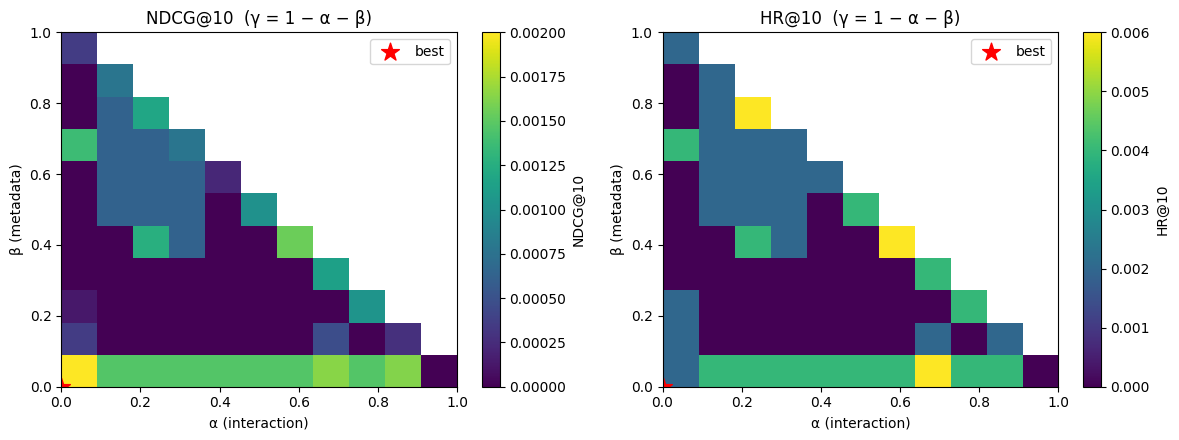

In [24]:
# Heatmap over the simplex (α on x, β on y; γ = 1 − α − β)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric in zip(axes, [f'NDCG@{K}', f'HR@{K}']):
    piv = grid_df.pivot_table(index='beta', columns='alpha', values=metric)
    im = ax.imshow(piv.values, origin='lower', aspect='auto',
                   extent=[piv.columns.min(), piv.columns.max(), piv.index.min(), piv.index.max()])
    fig.colorbar(im, ax=ax, label=metric)
    ax.set_xlabel('α (interaction)'); ax.set_ylabel('β (metadata)')
    ax.set_title(f'{metric}  (γ = 1 − α − β)')
    ax.scatter([BEST_A], [BEST_B], c='red', marker='*', s=180, label='best')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'fig_alpha_beta_gamma.png', dpi=140)
plt.show()

## Step 10 — Final comparison on test (K = 10)

Four rows, identical evaluation protocol, K = 10 throughout — exactly what the professor asked for. The pure-Item-CF row (α = 1) is the ablation sanity check; if that row matches Phase 1, the comparison is honest. The CB-ItemCF row uses the best (α, β, γ) from Step 9.

In [25]:
# 10a. Popularity baseline — rank items by train review count (excluding seen items per user)
item_pop    = np.asarray((R_train > 0).sum(axis=0)).ravel()  # train popularity (nnz per column)
pop_order   = np.argsort(-item_pop)

def pop_topk(u, k):
    seen = set(R_train.indices[R_train.indptr[u]:R_train.indptr[u+1]].tolist())
    out = []
    for i in pop_order:
        if int(i) in seen: continue
        out.append(int(i))
        if len(out) >= k: break
    return out

# 10b. Pure Item-CF (α=1): sanity check vs Phase-1 Item-CF
def itemcf_topk(u, k): return top_k_for_user(u, 1.0, 0.0, 0.0, k=k)

# 10c. Pure content reference (α=0, β=γ=0.5)
def content_topk(u, k): return top_k_for_user(u, 0.0, 0.5, 0.5, k=k)

# 10d. CB-ItemCF at best (α, β, γ)
def cb_topk(u, k): return top_k_for_user(u, BEST_A, BEST_B, BEST_G, k=k)

results = []
results.append(evaluate(pop_topk,     test_relevant, name='Popularity'))
results.append(evaluate(itemcf_topk,  test_relevant, name='Pure Item-CF (α=1)'))
results.append(evaluate(content_topk, test_relevant, name='Pure Content (α=0, β=γ=0.5)'))
results.append(evaluate(cb_topk,      test_relevant,
                        name=f'CB-ItemCF (α={BEST_A}, β={BEST_B}, γ={BEST_G})'))

eval Popularity:   0%|          | 0/1000 [00:00<?, ?it/s]

eval Pure Item-CF (α=1):   0%|          | 0/1000 [00:00<?, ?it/s]

eval Pure Content (α=0, β=γ=0.5):   0%|          | 0/1000 [00:00<?, ?it/s]

eval CB-ItemCF (α=0.0, β=0.0, γ=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

In [26]:
# 10f. Final table
metric_cols = [f'HR@{K}', f'NDCG@{K}', f'Recall@{K}', f'Coverage@{K}', f'Diversity@{K}']
rows = []
for r in results:
    rows.append({'Model': r['model'],
                 **{c: round(float(r.get(c, float('nan'))), 4) for c in metric_cols},
                 'n': r.get('n_evaluated', 0)})
final_df = pd.DataFrame(rows)
print(final_df.to_string(index=False))
final_df.to_csv(ARTIFACTS_DIR / 'comparative_k10.csv', index=False)
(ARTIFACTS_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, default=float))

                          Model  HR@10  NDCG@10  Recall@10  Coverage@10  Diversity@10    n
                     Popularity  0.054   0.0106     0.0140       0.0008        0.8915 1000
             Pure Item-CF (α=1)  0.007   0.0011     0.0022       0.0853        0.8051 1000
    Pure Content (α=0, β=γ=0.5)  0.001   0.0006     0.0010       0.1175        0.5404 1000
CB-ItemCF (α=0.0, β=0.0, γ=1.0)  0.002   0.0002     0.0003       0.1134        0.5631 1000


2380

## Step 11 — Cold-item slice

This is the result that justifies the whole variant. Split the test items by training popularity into head (≥100 ratings), torso (10–99), tail (<10), then re-evaluate per slice. The whole pitch was: pure Item-CF has nothing to work with on tail items, but S_meta + S_sem do. If CB-ItemCF beats Item-CF on the tail slice, the metadata is doing real work.

{'head': 6478, 'torso': 32603, 'tail': 35159}
           Model slice  HR@10  NDCG@10   n
      Popularity  head 0.0609   0.0123 886
      Popularity torso 0.0000   0.0000 476
      Popularity  tail 0.0000   0.0000 248
    Pure Item-CF  head 0.0023   0.0005 886
    Pure Item-CF torso 0.0063   0.0007 476
    Pure Item-CF  tail 0.0081   0.0014 248
    Pure Content  head 0.0011   0.0007 886
    Pure Content torso 0.0000   0.0000 476
    Pure Content  tail 0.0000   0.0000 248
CB-ItemCF (ours)  head 0.0000   0.0000 886
CB-ItemCF (ours) torso 0.0021   0.0002 476
CB-ItemCF (ours)  tail 0.0040   0.0007 248


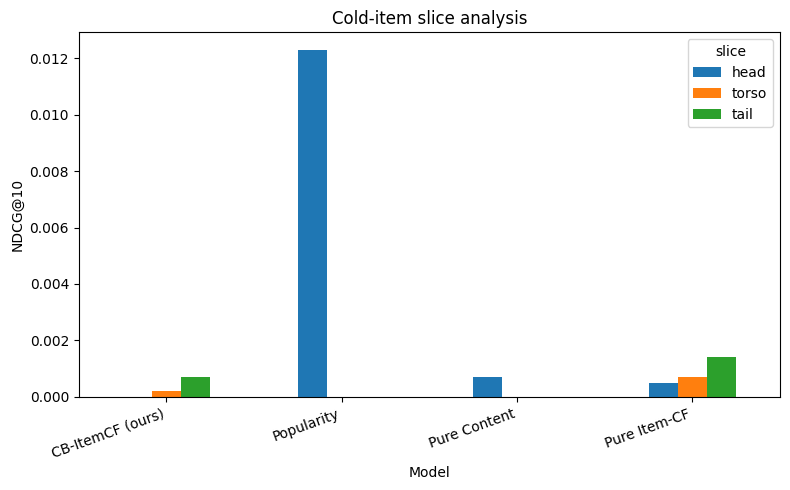

In [27]:
item_train_count = np.asarray((R_train > 0).sum(axis=0)).ravel()
slice_mask = {
    'head' : item_train_count >= 100,
    'torso': (item_train_count >= 10) & (item_train_count < 100),
    'tail' : item_train_count < 10,
}
print({s: int(m.sum()) for s, m in slice_mask.items()})

def eval_on_slice(topk_fn, relevant_dict, mask, k=K, n_sample=EVAL_USER_SAMPLE, seed=SEED):
    users = sample_eval_users(relevant_dict, n_sample, seed=seed)
    hits = ndcgs = n = 0
    for u in users:
        rel = {i for i in relevant_dict.get(u, set()) if mask[i]}
        if not rel: continue
        recs = topk_fn(u, k)
        hits  += hr_at_k(recs, rel, k)
        ndcgs += ndcg_at_k(recs, rel, k)
        n     += 1
    return {f'HR@{k}':   (hits / n) if n else 0.0,
            f'NDCG@{k}': (ndcgs / n) if n else 0.0,
            'n': n}

slice_rows = []
for name, tk in [('Popularity', pop_topk),
                 ('Pure Item-CF', itemcf_topk),
                 ('Pure Content', content_topk),
                 ('CB-ItemCF (ours)', cb_topk)]:
    for sname, m in slice_mask.items():
        r = eval_on_slice(tk, test_relevant, m)
        slice_rows.append({'Model': name, 'slice': sname,
                           f'HR@{K}': round(r[f'HR@{K}'], 4),
                           f'NDCG@{K}': round(r[f'NDCG@{K}'], 4),
                           'n': r['n']})
slice_df = pd.DataFrame(slice_rows)
print(slice_df.to_string(index=False))
slice_df.to_csv(ARTIFACTS_DIR / 'cold_item_slice.csv', index=False)

pivot = slice_df.pivot(index='Model', columns='slice', values=f'NDCG@{K}')
fig, ax = plt.subplots(figsize=(8, 5))
pivot[['head','torso','tail']].plot(kind='bar', ax=ax)
ax.set_ylabel(f'NDCG@{K}'); ax.set_title('Cold-item slice analysis')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'fig_cold_item_slices.png', dpi=140)
plt.show()